## DX799S O1 Data Science Capstone (Summer 1 2025): ACTIVITY 8.2 ##

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone Two, create a Jupyter Notebook (similar to in Module B, Semester Two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions. 

For this week, include ideas such as K-Nearest Neighbors and distance metrics. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 12, you will compile your findings from your Jupyter Notebook homework into your Milestone Two assignment for grading. For full instructions and the rubric for Milestone Two, refer to the following link. 

In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


The following dataset, "Video Review", is a collection of information that was created based on reviewable video evidence that outlines the events that resulted in a concussion during punt players in the NFL 2016-2017 season. The target, Primary_Impact_Type, outlines if the concussion occurred from the impact of Helmet-to-Helmet, Helmet-to-Body, or Helmet-to-Ground.

In [97]:
#Video Review Dataset 

df_videoreview = pd.read_csv("video_review.csv")

label_encoder = LabelEncoder()

print("Object columns before encoding:")
print(df_videoreview.select_dtypes(include=['object']).columns)

for col in df_videoreview.select_dtypes(include=['object']).columns:
    df_videoreview[col] = label_encoder.fit_transform(df_videoreview[col].astype(str))


target_column = 'Primary_Impact_Type'  
X_video = df_videoreview.drop(columns=[target_column])
y_video = df_videoreview[target_column]

X_train, X_test, y_train, y_test = train_test_split(X_video, y_video, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled_video = scaler.fit_transform(X_video)



Object columns before encoding:
Index(['Player_Activity_Derived', 'Turnover_Related', 'Primary_Impact_Type',
       'Primary_Partner_GSISID', 'Primary_Partner_Activity_Derived',
       'Friendly_Fire'],
      dtype='object')


In [98]:
#Video Review Dataset KNN

video_param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
    'algorithm': ['auto', 'brute']
}

video_knn = KNeighborsClassifier()

video_grid_search = GridSearchCV(
    estimator=video_knn,
    param_grid=video_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

video_grid_search.fit(X_scaled_video, y_video)

print("Best Parameters for Video Review Dataset:", video_grid_search.best_params_)
print("Best Cross-Validated Accuracy for Video Review Dataset:", video_grid_search.best_score_)



Fitting 5 folds for each of 320 candidates, totalling 1600 fits


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters for Video Review Dataset: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 18, 'weights': 'uniform'}
Best Cross-Validated Accuracy for Video Review Dataset: 0.625


Metrics in results: ['euclidean' 'manhattan' 'minkowski' 'cosine']


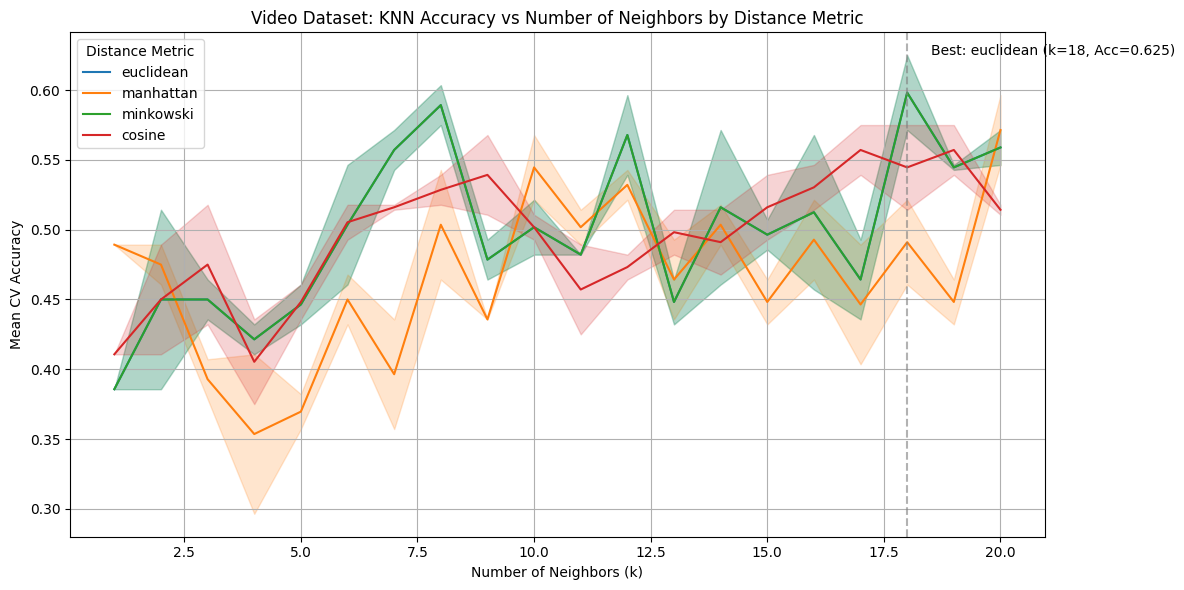

In [99]:
#Video Dataset Metric Comparison Graph 

video_results_df = pd.DataFrame(video_grid_search.cv_results_).rename(columns={
    'param_n_neighbors': 'n_neighbors',
    'param_metric': 'metric'
})

print("Metrics in results:", video_results_df['metric'].unique())

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=video_results_df,
    x='n_neighbors',
    y='mean_test_score',
    hue='metric',
    palette='tab10'
)

best_row = video_results_df.loc[video_results_df['mean_test_score'].idxmax()]
plt.axvline(x=best_row['n_neighbors'], color='gray', linestyle='--', alpha=0.6)
plt.text(
    x=best_row['n_neighbors'] + 0.5,
    y=best_row['mean_test_score'],
    s=f"Best: {best_row['metric']} (k={best_row['n_neighbors']}, Acc={best_row['mean_test_score']:.3f})",
    color='black'
)

plt.title('Video Dataset: KNN Accuracy vs Number of Neighbors by Distance Metric')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
plt.legend(title='Distance Metric')
plt.tight_layout()
plt.show()
()
plt.show()


The next dataset, Injury Record, looks to determine the relationship between the playing surface and the injury and performance of NFL athletes. The Injury Record dataset accounts for 105 lower-limbs injuries that occurred over two seasons during the regular NFL season and provides information on the surface the game occurred on and the number of days the player missed due to injury (or how severe it was). The target in this case is surface which lists the type of surface (synethic or natural) the field was when the injury occurred.

In [100]:
#Injury Record Dataset 

injury_df = pd.read_csv("InjuryRecord.csv")

injury_label_encoder = LabelEncoder()

print("Object columns before encoding:")
print(injury_df.select_dtypes(include=['object']).columns)

for col in injury_df.select_dtypes(include=['object']).columns:
    injury_df[col] = injury_label_encoder.fit_transform(injury_df[col].astype(str))

injury_target_column = 'Surface'
X_injury = injury_df.drop(columns=[injury_target_column])
y_injury = injury_df[injury_target_column]

X_injury_train, X_injury_test, y_injury_train, y_injury_test = train_test_split(
    X_injury, y_injury, test_size=0.2, random_state=42
)

injury_scaler = StandardScaler()
X_injury_train_scaled = injury_scaler.fit_transform(X_injury_train)


Object columns before encoding:
Index(['GameID', 'PlayKey', 'BodyPart', 'Surface'], dtype='object')


In [101]:
#Injury Record Dataset KNN

injury_param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
    'algorithm': ['auto', 'brute']
}

injury_knn = KNeighborsClassifier()

injury_grid_search = GridSearchCV(
    estimator=injury_knn,
    param_grid=injury_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

injury_grid_search.fit(X_injury_train_scaled, y_injury_train)

print("Best Parameters for Injury Record Dataset:", injury_grid_search.best_params_)
print("Best Cross-Validated Accuracy for Injury Record Dataset:", injury_grid_search.best_score_)



Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Parameters for Injury Record Dataset: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'uniform'}
Best Cross-Validated Accuracy for Injury Record Dataset: 0.4772058823529412


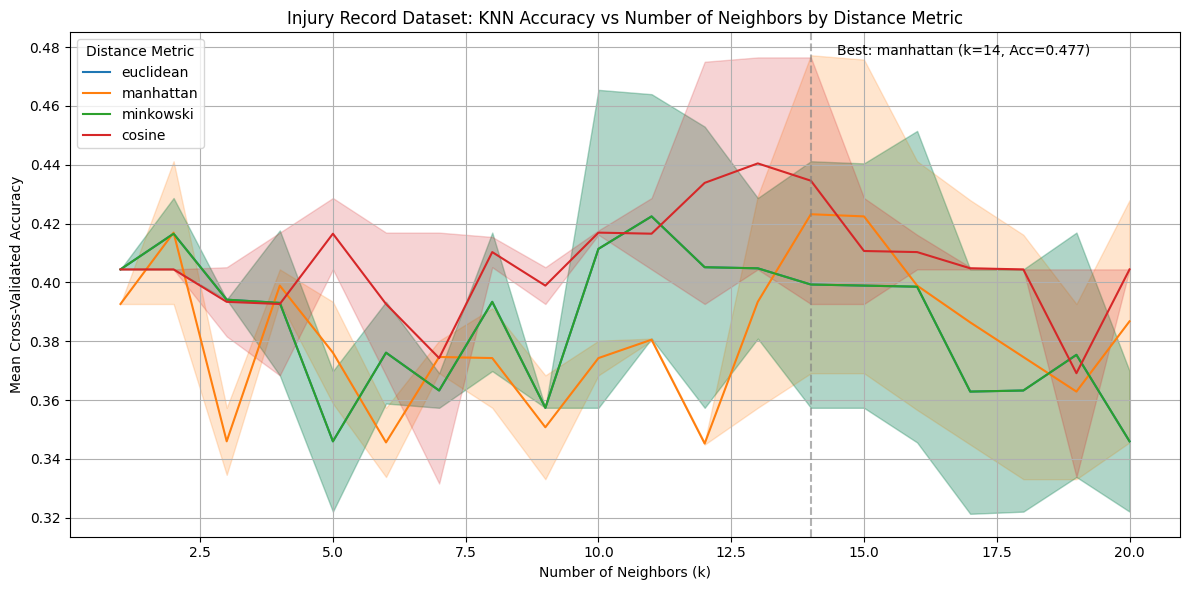

In [102]:
#Injury Record Dataset Metric Comparison Graph 

injury_results_df = pd.DataFrame(injury_grid_search.cv_results_).rename(columns={
    'param_n_neighbors': 'n_neighbors',
    'param_metric': 'metric'
})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=injury_results_df,
    x='n_neighbors',
    y='mean_test_score',
    hue='metric',
    palette='tab10',

)

best_row = injury_results_df.loc[injury_results_df['mean_test_score'].idxmax()]
plt.axvline(x=best_row['n_neighbors'], color='gray', linestyle='--', alpha=0.6)
plt.text(
    x=best_row['n_neighbors'] + 0.5,
    y=best_row['mean_test_score'],
    s=f"Best: {best_row['metric']} (k={best_row['n_neighbors']}, Acc={best_row['mean_test_score']:.3f})",
    color='black'
)

plt.title('Injury Record Dataset: KNN Accuracy vs Number of Neighbors by Distance Metric')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.grid(True)
plt.legend(title='Distance Metric')
plt.tight_layout()
plt.show()


The last dataset, Concussion, contains a list of concussion injuries that occurred in the National Football League from the year 2012 to 2014. The data includes features such as Position, Pre-Season Injury?, Week of Injury, Weeks Injured, Games Missed, Reported Injury Type, Average Playtime Before Injury, etc. The target in this case will be "Reported Injury Type" which will be limited to just concussions.

In [103]:
#Concussion Dataset 

df_concussion = pd.read_csv("Concussion Injuries 2012-2014 (1).csv")
df_clean_concussion = df_concussion.drop(columns=['ID', 'Player', 'Game', 'Date', 'Winning Team?', 'Unknown Injury?'])
df_clean_concussion = df_clean_concussion.dropna()

label_encoder = LabelEncoder()

for col in df_clean_concussion.select_dtypes(include=['object']).columns:
    df_clean_concussion[col] = label_encoder.fit_transform(df_clean_concussion[col].astype(str))

target_column = 'Reported Injury Type'  
X_concussion = df_clean_concussion.drop(columns=[target_column])
y_concussion = df_clean_concussion[target_column]

X_train_concussion, X_test_concussion, y_train_concussion, y_test_concussion = train_test_split(X_concussion, y_concussion, test_size=0.2, random_state=42)

concussion_scaler = StandardScaler()
X_train_scaled_concussion = concussion_scaler.fit_transform(X_train_concussion)

In [104]:
#Concussion Dataset KNN

concussion_param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
    'algorithm': ['auto', 'brute']
}

concussion_knn = KNeighborsClassifier()

concussion_grid_search = GridSearchCV(
    estimator=concussion_knn,
    param_grid=concussion_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

concussion_grid_search.fit(X_train_scaled_concussion, y_train_concussion)

print("Best Parameters for Concussion Dataset:", concussion_grid_search.best_params_)
print("Best Cross-Validated Accuracy for Concussion Dataset:", concussion_grid_search.best_score_)


Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Parameters for Concussion Dataset: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Cross-Validated Accuracy for Concussion Dataset: 0.8461538461538461


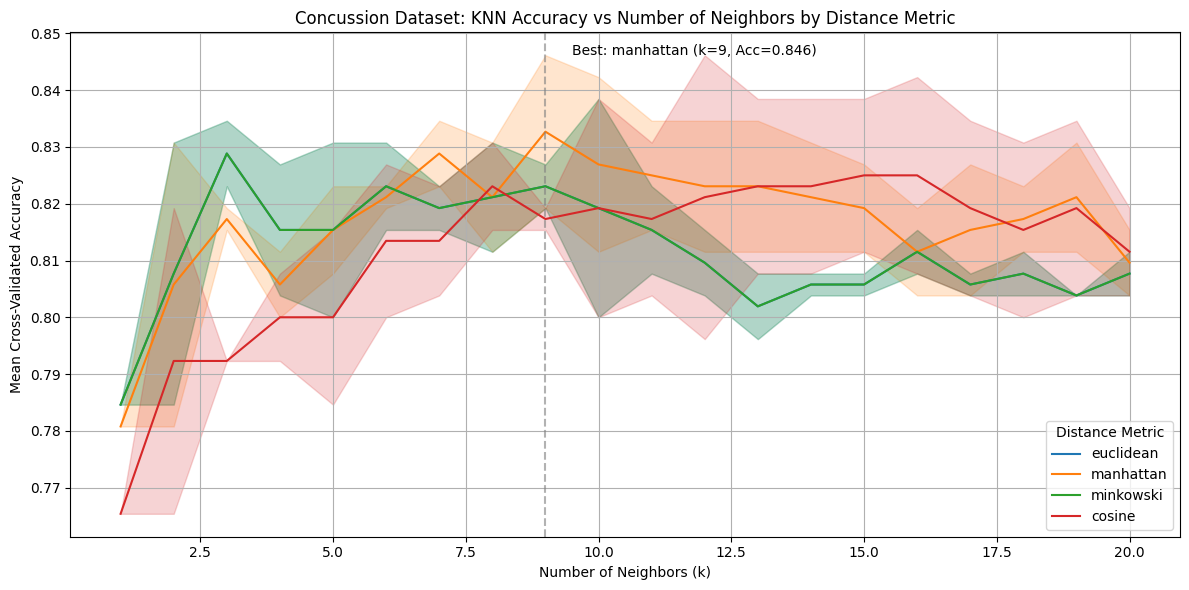

In [105]:
# Concussion Dataset Metric Comparison Graph 

concussion_results_df = pd.DataFrame(concussion_grid_search.cv_results_).rename(columns={
    'param_n_neighbors': 'n_neighbors',
    'param_metric': 'metric'
})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=concussion_results_df,
    x='n_neighbors',
    y='mean_test_score',
    hue='metric',
    palette='tab10'
)

best_row = concussion_results_df.loc[concussion_results_df['mean_test_score'].idxmax()]
plt.axvline(x=best_row['n_neighbors'], color='gray', linestyle='--', alpha=0.6)
plt.text(
    x=best_row['n_neighbors'] + 0.5,
    y=best_row['mean_test_score'],
    s=f"Best: {best_row['metric']} (k={best_row['n_neighbors']}, Acc={best_row['mean_test_score']:.3f})",
    color='black'
)

plt.title('Concussion Dataset: KNN Accuracy vs Number of Neighbors by Distance Metric')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.grid(True)
plt.legend(title='Distance Metric')
plt.tight_layout()
plt.show()
